# c_out

Cout Design
Given input current and power limitation, we want to have a steady input power.
Arctic P14 Pro PST is maximum 2500 rpm with 4-pole motor. Thus, at steady state max load, we expect a 16 Hz pulsing load. From measured data, we see it is approximately trapezoidal, and we can approximate as a 50% square wave.
This is much lower frequency and higher load ripple than the switching frequency, but we can check both.

Max Fan Load Power: 33.60W


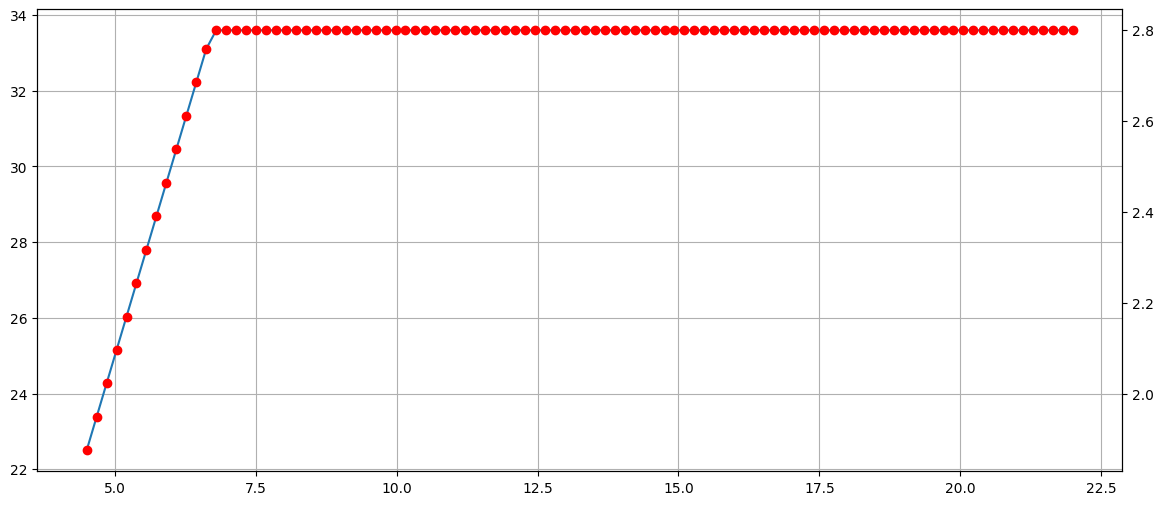

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#USB-C power sources, 5V to 20V, 5A
v_in_min_nominal = 5
v_in_max_nominal = 20
usb_c_v_tolerance = 0.1 # 10% tolerance
v_in = np.linspace(v_in_min_nominal*(1-usb_c_v_tolerance), v_in_max_nominal*(1+usb_c_v_tolerance), 100)
i_in_max = 5 # USB-C PD max current
i_in_nom_max = 3 # common USB-C maximum current
v_out = 12
fan_p14_pro_max_current = 0.35
fan_p14_pwm_max_current = 0.12
max_number_p14_pro = 8
max_load_watts = v_out * fan_p14_pro_max_current * max_number_p14_pro
print(f"Max Fan Load Power: {max_load_watts:.2f}W")

input_voltage_operating_points = v_in
input_current_operating_points_max = np.full_like(input_voltage_operating_points,i_in_nom_max)
f_sw = 100e3 # Assume we use minimum frequency. Helps lower switching mosfet losses. Though increases inductor core/ac losses.

# Calculate max power at each point: min(Available Input Power, Load Limit)
p_out_operating_points = np.minimum(max_load_watts, v_in * i_in_max)
i_out_operating_points = p_out_operating_points / v_out


fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
ax1.plot(v_in, p_out_operating_points, label='Output Power [W]')
ax2.plot(v_in, i_out_operating_points, 'o', color = "red", label='Output Current [A]')
ax1.grid()
plt.show()

## Output Voltage Ripple Due To Commutation

Max DC output current: 2.80 A
AC current amplitude: 2.80 A
Required capacitance: 8400.0 uF


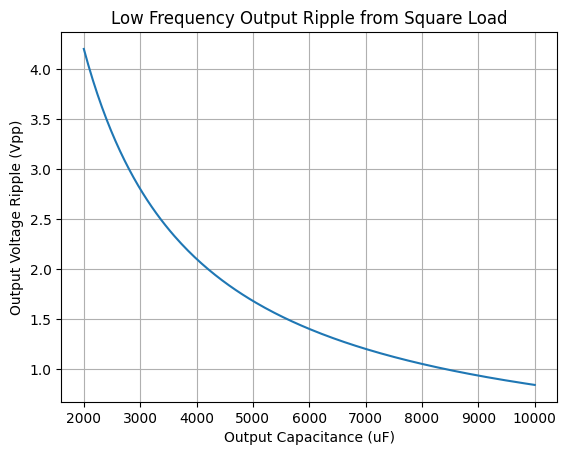

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
L = 47e-6          # Inductor Value from Buck_Boost_Initial_Calculations

load_square_freq = 2500/60*4
load_amplitude_factor = 1.0

i_dc_max = np.max(i_out_operating_points)

# AC amplitude
i_ac = i_dc_max * load_amplitude_factor

# Required capacitance for target ripple
goal_output_ripple_voltage = 1.0

c_required = i_ac / (2 * load_square_freq * goal_output_ripple_voltage)

print(f"Max DC output current: {i_dc_max:.2f} A")
print(f"AC current amplitude: {i_ac:.2f} A")
print(f"Required capacitance: {c_required*1e6:.1f} uF")


# RNL1E102MDS4
# 1000uf
# https://www.nichicon.co.jp/english/series_items/catalog_pdf/e-rnl.pdf
# https://www.digikey.com/en/products/detail/nichicon/RNL1E102MDS4/21317088

# https://www.digikey.com/en/products/detail/panasonic-electronic-components/EEU-FC1C472/266272
# MPN: EEU-FC1C472
# Digikey PN: P10263-ND
# 1 at $2.72, 10 at $1.46
# Ripple Current @ Low Frequency
# 2.559 A @ 120 Hz
# Ripple Current @ High Frequency
# 3.01 A @ 100 kHz
# load ripple of 2.8 A, so 2x of this capacitor is sufficient


# https://www.mouser.com/ProductDetail/Panasonic/ECA-1EHG472U?qs=0h1gzos03f1A4LfRGGZtVA%3D%3D

# Sweep capacitance values
c_out = np.linspace(2000e-6, 10000e-6, 200)

delta_v_pp = i_ac / (2 * load_square_freq * c_out)

plt.figure()
plt.plot(c_out*1e6, delta_v_pp)
plt.xlabel("Output Capacitance (uF)")
plt.ylabel("Output Voltage Ripple (Vpp)")
plt.title("Low Frequency Output Ripple from Square Load")
plt.grid(True)
plt.show()


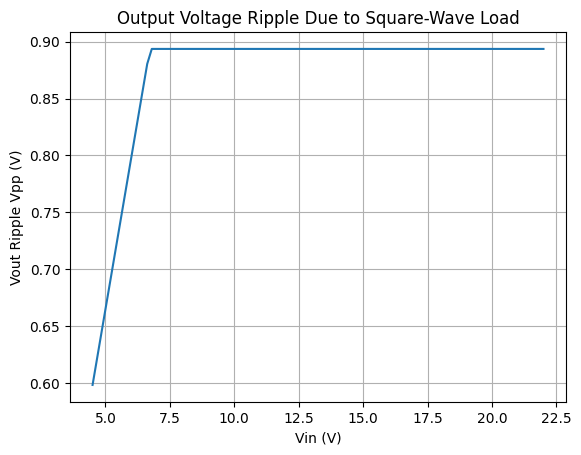

In [16]:
c_out = 2 * 4.7e-3  # 2 × 4.7 mF = 9.4 mF

# AC amplitude
i_ac = i_out_operating_points * load_amplitude_factor

# Output ripple voltage (peak-to-peak)
delta_v_out_pp = i_ac / (2 * load_square_freq * c_out)

# Optional: Plot vs Vin (ripple is independent of Vin in this simplified case)
plt.figure()
plt.plot(v_in, delta_v_out_pp * np.ones_like(v_in))
plt.xlabel("Vin (V)")
plt.ylabel("Vout Ripple Vpp (V)")
plt.title("Output Voltage Ripple Due to Square-Wave Load")
plt.grid(True)
plt.show()

## Output Current Ripple Due To Switching in Boost Mode

1.3875630851960046


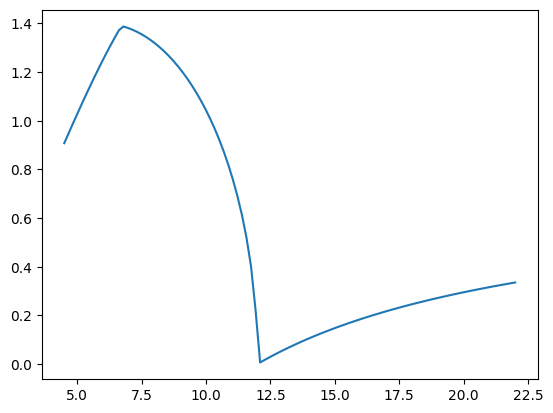

In [ ]:
# Duty cycle (ideal CCM)
D = np.where(
    v_in >= v_out,
    v_out / v_in,              # buck
    1 - v_in / v_out           # boost
)

# Inductor ripple (valid for both modes if written carefully)
delta_i_l = np.where(
    v_in >= v_out,
    ((v_in - v_out) * D) / (L * f_sw),   # buck
    (v_in * D) / (L * f_sw)              # boost
)

# Buck: ripple-based
i_cout_buck = delta_i_l / np.sqrt(12)

# Boost: duty-based
i_cout_boost = i_out_operating_points * np.sqrt(D * (1 - D))

# Combine
i_cout_rms = np.where(
    v_in >= v_out,
    i_cout_buck,
    i_cout_boost
)

print(np.max(i_cout_rms))
plt.plot(v_in, i_cout_rms)

# output ripple of 1.4A at 100kHz is within limits of output capacitors

## Output Voltage Ripple Due To Switching

Worst case ripple: 0.026491281610430538


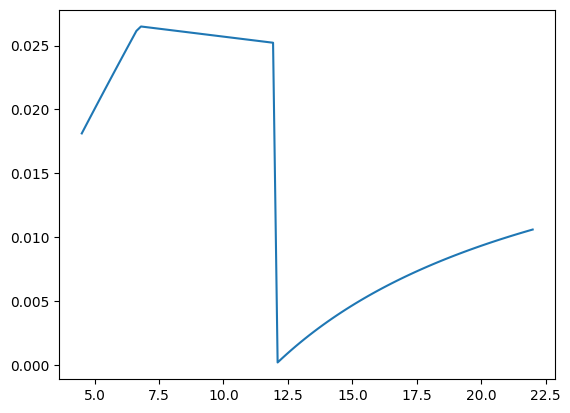

In [ ]:
c_out = 4.7e-3 * 2
esr_out = 0.018 / 2
# Duty cycle
D = np.where(
    v_in >= v_out,
    v_out / v_in,              # buck
    1 - v_in / v_out           # boost
)

# Inductor ripple
delta_i_l = np.where(
    v_in >= v_out,
    ((v_in - v_out) * D) / (L * f_sw),  # buck
    (v_in * D) / (L * f_sw)             # boost
)

# --- Capacitive ripple ---

delta_v_c = np.where(
    v_in >= v_out,
    delta_i_l / (8 * f_sw * c_out),         # buck
    (i_out_operating_points * D) / (f_sw * c_out)  # boost
)

# --- ESR ripple ---

delta_v_esr = np.where(
    v_in >= v_out,
    delta_i_l * esr_out,                   # buck
    i_out_operating_points * esr_out       # boost
)

# --- Total ripple (approx peak-to-peak sum) ---

delta_v_total = delta_v_c + delta_v_esr

print("Worst case ripple:", np.max(delta_v_total))
plt.plot(v_in, delta_v_total)

# switching voltage ripple is very small compared to ripple due to square wave load


# Cin

 Max Input Ripple: 1.39 A rms


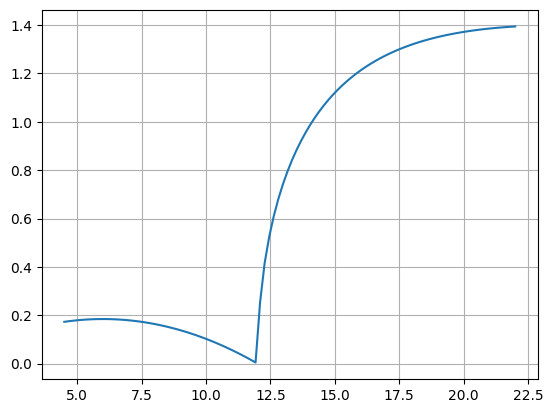

In [7]:
D = np.where(
    v_in >= v_out,
    v_out / v_in,              # buck
    1 - v_in / v_out           # boost
)

# Buck input cap RMS
i_cin_buck = i_out_operating_points * np.sqrt(D * (1 - D))

# Boost inductor ripple
delta_i_l = (v_in * D) / (L * f_sw)

i_cin_boost = delta_i_l / np.sqrt(12)

# Combine modes
i_cin_rms = np.where(
    v_in >= v_out,
    i_cin_buck,
    i_cin_boost
)

print(f" Max Input Ripple: {np.max(i_cin_rms):.2f} A rms")
plt.plot(v_in, i_cin_rms)
plt.grid()


In [ ]:
i_rms = 1.39      # A
f_sw = 100e3      # Hz
delta_v_target = 0.5  # V

c_in_required = i_rms / (2 * np.pi * f_sw * delta_v_target)
print(f"Minimum input capacitance needed: {c_in_required*1e6:.1f} uF")

# https://www.digikey.com/en/products/detail/rubycon/35ZLJ47M5X11/3562956
# 47 uF aluminum electrolytic is cheap
# 450 mA ripple current at 100 kHz
# 0.4 Ohm impedance at 100 kHz
# Choose to use 4x 47 uF aluminum electrolytic
# 0.1 Ohm total parallel impedance so approximately 0.139 V ripple

Minimum input capacitance needed: 4.4 uF


# Final Conclusion

In [ ]:
output_cap = "2x 4.7mF 16V EEU-FC1c472" # https://www.digikey.com/en/products/detail/panasonic-electronic-components/EEU-FC1C472/266272
# MPN: EEU-FC1C472
# Digikey PN: P10263-ND"
# better actually 25V instead of 16V, want 2x voltage rating
# or 25v caps https://www.digikey.com/en/products/detail/rubycon/25PK4700MEFC16X25/3564433
# https://www.digikey.com/en/products/detail/chemi-con/EKYB250ELL472MM25S/4843714
input_cap = "4x 47uF 35V aluminum electrolytic 1189-2272-ND" # https://www.digikey.com/en/products/detail/rubycon/35ZLJ47M5X11/3562956